# GREA MCMC analysis — getdist triangle plots

Analyse Cobaya chains (PP+DESI and any other CCG runs) copied from Stanage.

**Workflow:** point `CHAINS_DIR` at the folder you copied over → the notebook lists
every run it finds → you pick one or several → it loads them with burn-in removed,
reports Gelman–Rubin convergence and the 68% marginalised constraints, then makes
overlaid getdist triangle plots.

Each Cobaya run is identified by its `<root>.updated.yaml` file, so you can drop
several run folders under `CHAINS_DIR` and overlay them (e.g. GREA vs ΛCDM, or the
five CCG configurations).

Requires: `getdist`, `matplotlib`, `numpy` (`pip install getdist`).

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, loadMCSamples

# ---- Configuration ---------------------------------------------------------
CHAINS_DIR = "."    # notebook lives in ANALYSIS/; "." searches it recursively
IGNORE_ROWS = 0.3    # burn-in fraction removed at load time
OUT_DIR = "figs"  # where triangle plots are written
os.makedirs(OUT_DIR, exist_ok=True)

HEADLINE_PARAMS = ["sqrt_k_eta0", "H0", "Omega_m", "sigma8", "S8"]
FULL_PARAMS = ["sqrt_k_eta0", "logA", "n_s", "omega_b", "omega_cdm",
               "H0", "Omega_m", "sigma8", "S8", "tau_reio"]

# Optional reference lines (e.g. Planck 2018 ΛCDM). Set to None to disable.
# MARKERS = {"H0": 67.36, "Omega_m": 0.3153, "sigma8": 0.8111, "S8": 0.832}
MARKERS = None

# Per-dataset legend labels and contour colours for the corner plots.
# Must have the same length as the number of selected runs, or be None for auto.
LABELS = None   # e.g. ["GREA PP+DESI", "LCDM PP+DESI"]
COLORS = None   # e.g. ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

In [2]:
import scienceplots  # registers the "science" matplotlib style

plt.style.use(['science'])

## 1. Discover the runs

Each Cobaya run is found by its `<root>.updated.yaml` paired with sibling `.txt`
chains. The expected layout (matching the copied tree) is:

```
ANALYSIS/                         <- CHAINS_DIR = "."  (this notebook lives here)
  grea_Run1_PP+DESI/
    chains/
      chains.1.txt ... chains.4.txt
      chains.updated.yaml
    PP+DESI_GREA.yaml
  class_public-3.3.4/   cobaya/   <- ignored: no chains next to any stray yaml
```

The run is labelled by its folder (`grea_Run1_PP+DESI`), and the redundant
`chains/chains` Cobaya prefix is collapsed away. Drop more run folders alongside
it and they'll be discovered too.

In [3]:
def run_label(root, chains_dir):
    # Turn '.../grea_Run1_PP+DESI/chains/chains' into 'grea_Run1_PP+DESI'.
    parts = os.path.relpath(root, chains_dir).split(os.sep)
    # cobaya 'chains/chains' prefix
    if len(parts) >= 2 and parts[-1] == parts[-2]:
        parts = parts[:-1]
    if len(parts) >= 2 and parts[-1] == "chains":     # trailing 'chains' dir
        parts = parts[:-1]
    return os.sep.join(parts) if parts else os.path.basename(root)


def discover_runs(chains_dir=CHAINS_DIR):
    # One run == one '<root>.updated.yaml' that has sibling chain '.txt' files.
    runs = {}
    for y in sorted(glob.glob(os.path.join(chains_dir, "**", "*.updated.yaml"),
                              recursive=True)):
        root = y[:-len(".updated.yaml")]
        has_chains = glob.glob(
            root + ".*.txt") or os.path.exists(root + ".txt")
        if not has_chains:
            # skip stray yamls (class_public/, cobaya/, ...)
            continue
        runs[run_label(root, chains_dir)] = root
    return runs


runs = discover_runs()
if not runs:
    raise FileNotFoundError(
        f"No Cobaya runs (*.updated.yaml + .txt chains) found under '{CHAINS_DIR}/'. "
        "Check CHAINS_DIR points at the main analysis folder.")

print("Available runs:")
for i, label in enumerate(runs):
    print(f"  [{i}] {label}  ->  {runs[label]}")

Available runs:
  [0] grea_Run1_PP+DESI  ->  ./grea_Run1_PP+DESI/chains/chains
  [1] grea_Run3_CMB-SPA+PP+DESI  ->  ./grea_Run3_CMB-SPA+PP+DESI/chains/chains
  [2] grea_Run4_PPS+DESI  ->  ./grea_Run4_PPS+DESI/chains/chains
  [3] grea_Run5_CMB-SPA+PPS+DESI  ->  ./grea_Run5_CMB-SPA+PPS+DESI/chains/chains


## 2. Select runs

All discovered runs are selected automatically. To restrict to a subset, set
`SELECTION` to a list of indices (e.g. `[0]` or `[0, 2]`); `None` means *all*.

In [4]:
# [0] or [0, 2] to restrict; None -> all discovered runs
SELECTION = [0, 1, 2]

run_labels = list(runs)
if SELECTION is None:
    SELECTION = list(range(len(run_labels)))

chosen = [run_labels[i] for i in SELECTION]

# Resolve display labels and colours (fall back to sensible defaults if not set).
_default_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
]
run_colors = COLORS if COLORS is not None else _default_colors[:len(chosen)]
run_labels_display = LABELS if LABELS is not None else list(chosen)

# Write selected run names to a file so this choice is reproducible.
with open(os.path.join(OUT_DIR, "selected_runs.txt"), "w") as fh:
    for lbl, col, disp in zip(chosen, run_colors, run_labels_display):
        fh.write(f"{lbl}\t{col}\t{disp}\n")

print("Selected runs (written to figs/selected_runs.txt):")
for disp, col, lbl in zip(run_labels_display, run_colors, chosen):
    print(f"  [{col}]  {disp!r:30s}  ({lbl})")

Selected runs (written to figs/selected_runs.txt):
  [#1f77b4]  'grea_Run1_PP+DESI'             (grea_Run1_PP+DESI)
  [#ff7f0e]  'grea_Run3_CMB-SPA+PP+DESI'     (grea_Run3_CMB-SPA+PP+DESI)
  [#2ca02c]  'grea_Run4_PPS+DESI'            (grea_Run4_PPS+DESI)


## 3. Load chains + convergence

Burn-in (`IGNORE_ROWS`) is stripped on load. `R-1` is the worst Gelman–Rubin
statistic across the (non-derived) sampled parameters — you want it well below
~0.05, ideally < 0.01.

In [5]:
samples = {}
for label in chosen:
    s = loadMCSamples(runs[label], settings={"ignore_rows": IGNORE_ROWS})
    samples[label] = s
    n_chains = len(s.getSeparateChains())
    try:
        rm1 = s.getGelmanRubin()
        conv = f"R-1(worst) = {rm1:.4f}"
    except Exception as e:                      # e.g. single chain / degenerate
        conv = f"R-1 unavailable ({type(e).__name__})"
    print(f"{label}: {int(s.numrows)} samples | {n_chains} chain(s) | {conv}")

grea_Run1_PP+DESI: 17810 samples | 4 chain(s) | R-1(worst) = 0.0162
grea_Run3_CMB-SPA+PP+DESI: 10396 samples | 4 chain(s) | R-1(worst) = 0.0116
grea_Run4_PPS+DESI: 11621 samples | 4 chain(s) | R-1(worst) = 0.0086


### Inspect available parameters (optional)

Use this to discover the exact parameter names in a run, so you can tune
`HEADLINE_PARAMS` / `FULL_PARAMS`. (`S8`, `Omega_m`, etc. only appear if they
were defined as derived parameters in the run's YAML.)

In [6]:
for label, s in samples.items():
    print(f"--- {label} ---")
    for pn in s.getParamNames().names:
        kind = "derived" if pn.isDerived else "sampled"
        print(f"  {pn.name:16s} [{kind:7s}]  {pn.label}")
    break  # first run only; remove to list all

--- grea_Run1_PP+DESI ---
  logA             [sampled]  \log(10^{10} A_\mathrm{s})
  n_s              [sampled]  n_\mathrm{s}
  H0               [sampled]  H_0
  omega_b          [sampled]  \Omega_\mathrm{b} h^2
  omega_cdm        [sampled]  \Omega_\mathrm{c} h^2
  sqrt_k_eta0      [sampled]  \sqrt{k}\,\eta_0
  A_s              [derived]  A_\mathrm{s}
  Omega_m          [derived]  \Omega_\mathrm{m}
  sigma8           [derived]  \sigma_8
  S8               [derived]  S_8
  age              [derived]  {\rm{Age}}/\mathrm{Gyr}
  rs_drag          [derived]  r_\mathrm{drag}
  chi2__BAO        [derived]  \chi^2_\mathrm{BAO}
  chi2__SN         [derived]  \chi^2_\mathrm{SN}
  chi2             [derived]  \chi^2
  chi2__bao.desi_dr2 [derived]  \chi^2_\mathrm{bao.desi\ dr2}
  chi2__sn.pantheonplus [derived]  \chi^2_\mathrm{sn.pantheonplus}


## 4. Marginalised constraints (68%)

A concrete number before the contours. Note for GREA: σ₈ comes out *higher* than
ΛCDM at fixed A_s, so read S₈ accordingly when discussing the tension.

In [7]:
def print_constraints(samples_dict, params):
    for label, s in samples_dict.items():
        avail = s.getParamNames().list()
        present = [p for p in params if p in avail]
        print(f"=== {label} — 68% marginalised ===")
        for p in present:
            print("   " + s.getInlineLatex(p, limit=1))
        print()


print_constraints(samples, FULL_PARAMS)

=== grea_Run1_PP+DESI — 68% marginalised ===
   \sqrt{k}\,\eta_0 = 3.12\pm 0.13
   \log(10^{10} A_\mathrm{s}) = ---
   n_\mathrm{s} = ---
   \Omega_\mathrm{b} h^2 = 0.0262^{+0.013}_{-0.0070}
   \Omega_\mathrm{c} h^2 = 0.125^{+0.028}_{-0.022}
   H_0 = 70^{+10}_{-5}
   \Omega_\mathrm{m} = 0.3064\pm 0.0077
   \sigma_8 = 0.74^{+0.15}_{-0.35}
   S_8 = 0.75^{+0.15}_{-0.35}

=== grea_Run3_CMB-SPA+PP+DESI — 68% marginalised ===
   \sqrt{k}\,\eta_0 = 3.287\pm 0.093
   \log(10^{10} A_\mathrm{s}) = 3.0589\pm 0.0097
   n_\mathrm{s} = 0.9732\pm 0.0029
   \Omega_\mathrm{b} h^2 = 0.022460\pm 0.000093
   \Omega_\mathrm{c} h^2 = 0.11845\pm 0.00065
   H_0 = 67.83\pm 0.57
   \Omega_\mathrm{m} = 0.3078\pm 0.0052
   \sigma_8 = 0.8106\pm 0.0072
   S_8 = 0.8210\pm 0.0062
   \tau_\mathrm{reio} = 0.0590\pm 0.0053

=== grea_Run4_PPS+DESI — 68% marginalised ===
   \sqrt{k}\,\eta_0 = 3.12\pm 0.13
   \log(10^{10} A_\mathrm{s}) = ---
   n_\mathrm{s} = ---
   \Omega_\mathrm{b} h^2 = 0.0304\pm 0.0020
   \Omega_\mathr

## 5. Triangle plots

Overlaid filled contours. For multi-run overlays only parameters present in *all*
selected runs are shown (so e.g. `sqrt_k_eta0` drops out of a GREA-vs-ΛCDM
comparison, which is the correct shared basis).

Not in all selected runs, skipped: ['tau_reio']
Saved figs/grea_full_triangle.pdf


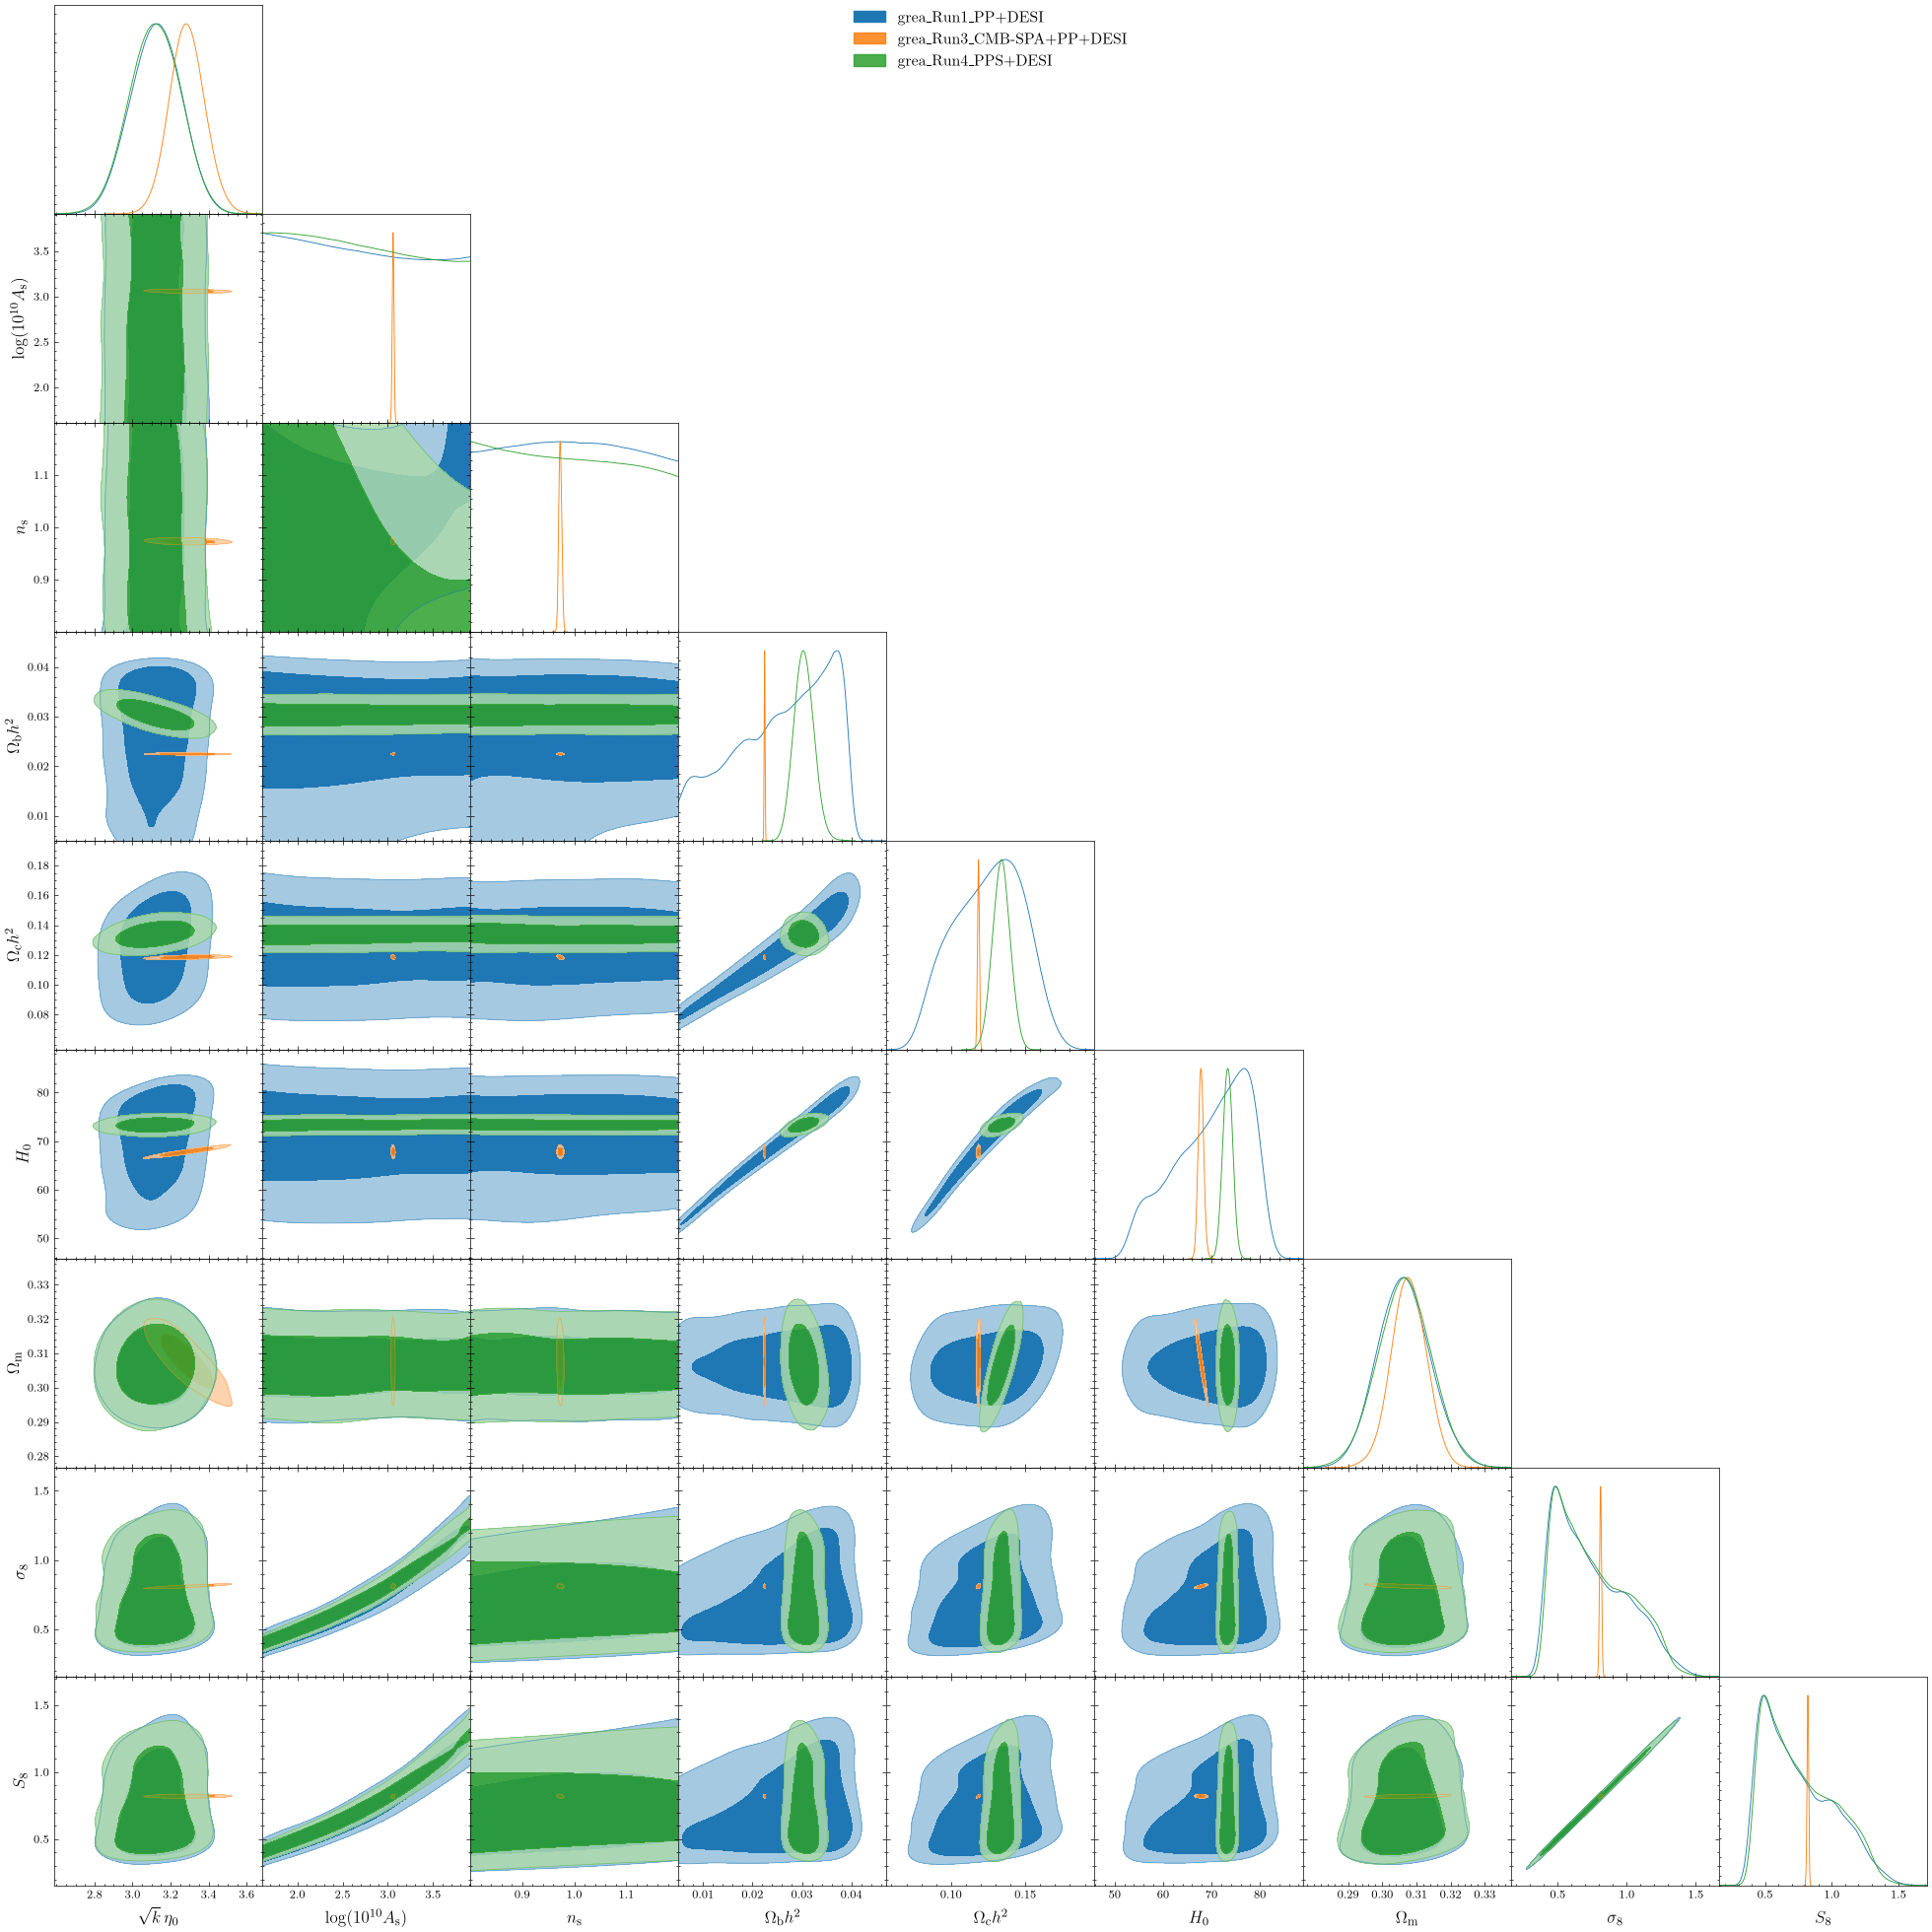

In [10]:
# Full parameter triangle
_ = triangle(samples, FULL_PARAMS, "grea_full_triangle.pdf",
             colors=run_colors, display_labels=run_labels_display)

## Notes

- **Burn-in / convergence.** Cobaya may already trim some burn-in; `IGNORE_ROWS`
  removes an additional fraction at load. If `R-1` is borderline, raise it.
- **α recovery.** This notebook plots the directly-sampled `sqrt_k_eta0`. Recovering
  α (via the `brentq` `α ↔ sqrt_k_eta0` inversion, which needs full-cosmology CLASS
  calls) is a separate post-processing step — best run where the GREA-CLASS build is
  available, then added as a derived column with `samples.addDerived(...)`.
- **Overlays.** Put each run's files in its own subfolder under `CHAINS_DIR`; they're
  discovered automatically and can be selected together to overlay (GREA vs ΛCDM,
  or the five CCG configurations).
- **Customising parameters.** Use the "inspect parameters" cell to get exact names,
  then edit `HEADLINE_PARAMS` / `FULL_PARAMS`.

Saved figs/grea_headline_triangle.pdf


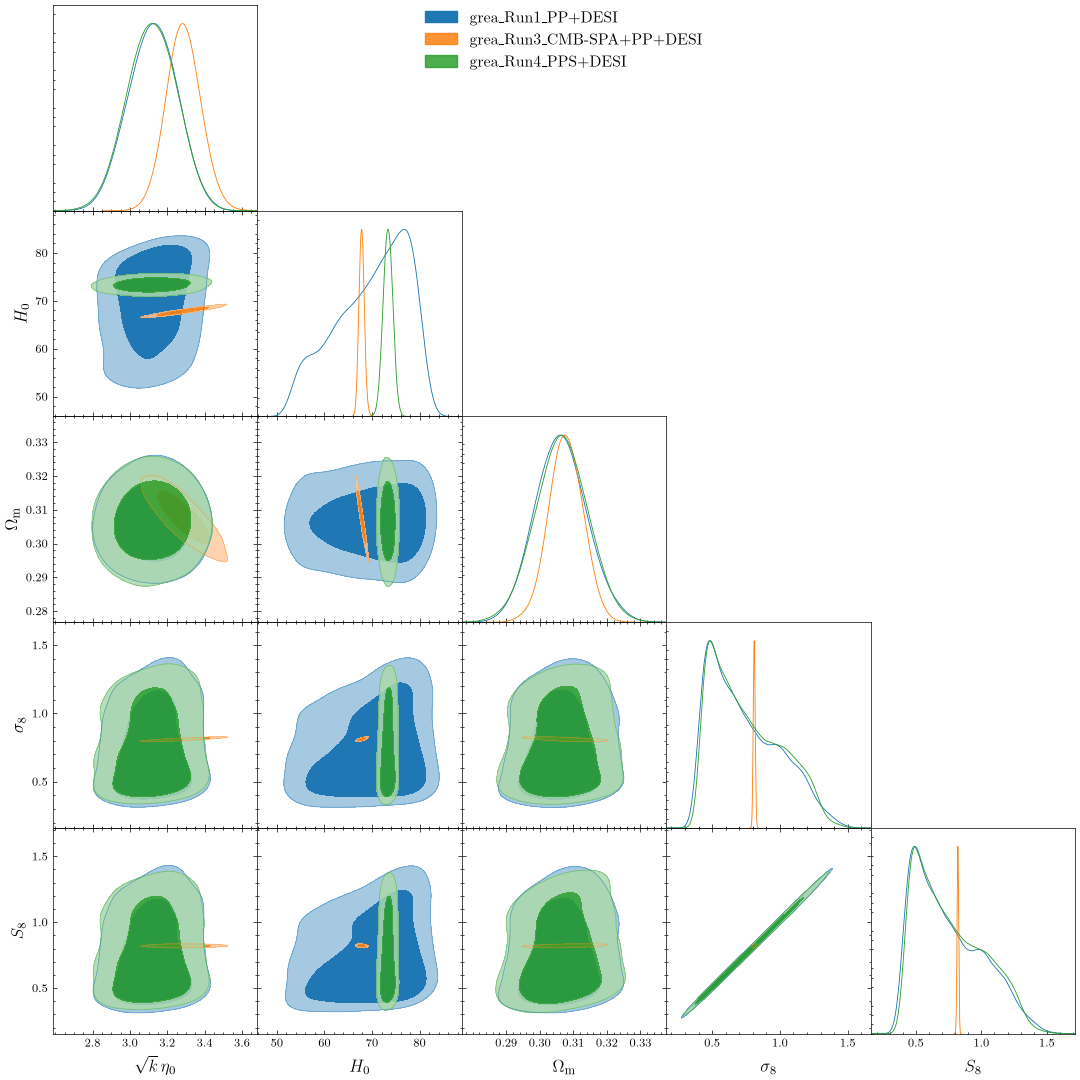

In [9]:
def triangle(samples_dict, params, fname,
             colors=None, display_labels=None,
             filled=True, markers=MARKERS):
    samps = list(samples_dict.values())
    labels = display_labels if display_labels is not None else list(
        samples_dict.keys())
    common = [p for p in params
              if all(p in s.getParamNames().list() for s in samps)]
    dropped = [p for p in params if p not in common]
    if dropped:
        print("Not in all selected runs, skipped:", dropped)
    if not common:
        raise ValueError("No shared parameters to plot.")

    g = plots.get_subplot_plotter(width_inch=2.2 * len(common))
    g.settings.legend_fontsize = 14
    g.settings.axes_fontsize = 11
    g.settings.axes_labelsize = 15
    g.triangle_plot(
        samps, common, filled=filled,
        legend_labels=labels if len(samps) > 1 else None,
        contour_colors=colors,
        markers={k: v for k, v in markers.items(
        ) if k in common} if markers else None,
    )
    out = os.path.join(OUT_DIR, fname)
    g.export(out)
    print("Saved", out)
    return g


_ = triangle(samples, HEADLINE_PARAMS, "grea_headline_triangle.pdf",
             colors=run_colors, display_labels=run_labels_display)

In [ ]:

# --- LaTeX table of 68% marginalised constraints (asymmetric errors from posterior quantiles) ---
import math
import os as _os
import sys as _sys

# ── alpha conversion ──────────────────────────────────────────────────────────
# alpha is the physical GREA parameter; CLASS samples sqrt_k_eta0.
#   alpha = sqrt_k_eta0 / K_ALPHA,   K_ALPHA = eta_0 * H0 / c
# where eta_0 = conformal time today (Mpc) from CLASS background table.
# K_ALPHA is evaluated at the posterior-mean cosmology.
# If CLASS import fails, set K_ALPHA manually here:
K_ALPHA = None   # e.g. K_ALPHA = 3.237

if K_ALPHA is None:
    try:
        _cwd = _os.getcwd()
        _class_python = None
        for _candidate in [
            _os.path.join(_cwd, "class_public-3.3.4",
                          "python"),       # cwd = CLASS/
            _os.path.join(_cwd, "..", "class_public-3.3.4",
                          "python"),  # cwd = CLASS/ANALYSIS/
        ]:
            if _os.path.isdir(_os.path.abspath(_candidate)):
                _class_python = _os.path.abspath(_candidate)
                break
        if _class_python is None:
            raise FileNotFoundError(
                "class_public-3.3.4/python not found near cwd")
        if _class_python not in _sys.path:
            _sys.path.insert(0, _class_python)

        from classy import Class as _Class

        _s0 = samples[chosen[0]]

        def _pmean(p, default):
            return float(_s0.getMargeStats().parWithName(p).mean) \
                if p in _s0.getParamNames().list() else default

        _H0 = _pmean("H0", 67.83)
        _bg = _Class()
        _bg.set({
            "H0":          _H0,
            "omega_b":     _pmean("omega_b",    0.02246),
            "omega_cdm":   _pmean("omega_cdm",  0.11845),
            "tau_reio":    _pmean("tau_reio",   0.059),
            "fluid_equation_of_state": "GREA",
            "sqrt_k_eta0": _pmean("sqrt_k_eta0", 3.287),
            "output": "",
        })
        _bg.compute()
        _eta0 = _bg.get_background()["conf. time [Mpc]"][-1]
        K_ALPHA = _eta0 * _H0 / 299792.458
        _bg.struct_cleanup()
        print(f"CLASS OK  ->  K_ALPHA = {K_ALPHA:.5f}  "
              f"(eta_0 = {_eta0:.1f} Mpc,  H0 = {_H0:.2f} km/s/Mpc)")
        print(
            f"alpha at posterior mean = {_pmean('sqrt_k_eta0', 3.287) / K_ALPHA:.4f}")
    except Exception as _e:
        print(f"CLASS unavailable: {_e}")
        print("Set K_ALPHA manually above (e.g. K_ALPHA = 3.237) to include the alpha row.")

# Add alpha = sqrt_k_eta0 / K_ALPHA as a derived parameter in each sample set
if K_ALPHA is not None:
    for rk in chosen:
        s = samples[rk]
        avail = s.getParamNames().list()
        if "sqrt_k_eta0" in avail and "alpha" not in avail:
            s.addDerived(
                s.getParams().sqrt_k_eta0 / K_ALPHA,
                name="alpha",
                label=r"\alpha",
            )
    print(
        f"'alpha' added as derived parameter  (alpha = sqrt_k_eta0 / {K_ALPHA:.5f})")

# ── Parameters to tabulate ───────────────────────────────────────────────────
TABLE_COSMO = (["alpha"] if K_ALPHA is not None else []) + [
    "sqrt_k_eta0",
    "logA",
    "n_s",
    "omega_b",
    "omega_cdm",
    "H0",
    "tau_reio",
]
TABLE_DERIVED = [
    "Omega_m",
    "sigma8",
    "S8",
    "age",
    "rs_drag",
]


def _weighted_stats(s, pname):
    """
    Return (mean, lower_68, upper_68) by computing weighted quantiles
    directly from MCMC samples.  Works for both original and addDerived()
    parameters, and is independent of getdist's internal stats cache.
    """
    param_list = s.getParamNames().list()
    if pname not in param_list:
        return None, None, None
    idx = param_list.index(pname)
    arr = s.samples[:, idx]
    w = s.weights if s.weights is not None else np.ones(len(arr))
    w = np.asarray(w, dtype=float)
    w /= w.sum()
    mean = float(np.dot(w, arr))
    sort_idx = np.argsort(arr)
    cdf = np.cumsum(w[sort_idx])
    arr_s = arr[sort_idx]
    lower = float(arr_s[np.searchsorted(cdf, 0.16, side="right")])
    upper = float(arr_s[np.searchsorted(cdf, 0.84, side="right")])
    return mean, lower, upper


def _asymfmt(mean, lower, upper, sig=2):
    """
    Format mean^{+d_up}_{-d_lo} to `sig` sig. figs. of the *smaller* deviation.
    Non-Gaussian asymmetries are fully preserved.
    """
    d_lo = mean - lower
    d_up = upper - mean
    ref = min(d_lo, d_up)
    if not (np.isfinite(ref) and ref > 0):
        return f"{mean:.4g}", None, None
    exp = math.floor(math.log10(ref))
    dp = max(0, sig - 1 - exp)
    return f"{mean:.{dp}f}", f"{d_up:.{dp}f}", f"{d_lo:.{dp}f}"


def latex_constraints_table(samples_dict, cosmo_params, derived_params,
                            caption="", tab_label="tab:constraints"):
    run_keys = list(samples_dict.keys())
    col_spec = "l" + "c" * len(run_keys)

    buf = []
    A = buf.append
    A(r"\begin{table}[ht]")
    A(r"\centering")
    if caption:
        A(rf"\caption{{{caption}}}")
    A(rf"\label{{{tab_label}}}")
    A(rf"\begin{{tabular}}{{{col_spec}}}")
    A(r"\hline\hline")
    headers = [k.replace("_", r"\_") for k in run_keys]
    A("Parameter & " + " & ".join(headers) + r" \\")
    A(r"\hline")

    def _add_block(params, block_title=None):
        if block_title:
            ncols = len(run_keys) + 1
            A(rf"\multicolumn{{{ncols}}}{{l}}{{\textit{{{block_title}}}}} \\")
        for pname in params:
            tex_label = None
            vals = []
            for rk in run_keys:
                s = samples_dict[rk]
                mean, lower, upper = _weighted_stats(s, pname)
                if mean is None:
                    vals.append("---")
                    continue
                if tex_label is None:
                    pobj = s.getParamNames().parWithName(pname)
                    tex_label = f"${pobj.label}$"
                m_s, up_s, lo_s = _asymfmt(mean, lower, upper)
                if up_s is None:
                    vals.append(f"${m_s}$")
                else:
                    vals.append(rf"${m_s}^{{+{up_s}}}_{{-{lo_s}}}$")
            if tex_label is None:
                tex_label = rf"\texttt{{{pname}}}"
            A(tex_label + " & " + " & ".join(vals) + r" \\")

    _add_block(cosmo_params, "Sampled parameters")
    A(r"\hline")
    _add_block(derived_params, "Derived parameters")
    A(r"\hline\hline")
    A(r"\end{tabular}")
    A(r"\end{table}")
    return "\n".join(buf)


_cap = (
    r"Marginalised 68\,\% constraints on GREA cosmological parameters "
    r"from the joint CMB-SPA\,+\,PantheonPlus\,+\,DESI\,DR2 dataset combination "
    r"(run \texttt{grea\_Run3\_CMB-SPA+PP+DESI}, "
    r"$R{-}1_{\rm worst} = 0.0116$, $N_{\rm eff} = 10396$ post burn-in). "
    r"Nuisance parameters ($T_{\rm cal}$, $E_{\rm cal}$, $A_{\rm planck}$, "
    r"$p_{\rm ACT}$) are omitted."
)

_table_src = latex_constraints_table(
    {k: samples[k] for k in chosen},
    TABLE_COSMO,
    TABLE_DERIVED,
    caption=_cap,
    tab_label="tab:grea_cmb_spa_pp_desi",
)
print(_table_src)

CLASS OK  ->  K_ALPHA = 3.23700  (eta_0 = 14307.2 Mpc,  H0 = 67.83 km/s/Mpc)
alpha at posterior mean = 1.0155
'alpha' added as derived parameter  (alpha = sqrt_k_eta0 / 3.23700)
\begin{table}[ht]
\centering
\caption{Marginalised 68\,\% constraints on GREA cosmological parameters from the joint CMB-SPA\,+\,PantheonPlus\,+\,DESI\,DR2 dataset combination (run \texttt{grea\_Run3\_CMB-SPA+PP+DESI}, $R{-}1_{\rm worst} = 0.0116$, $N_{\rm eff} = 10396$ post burn-in). Nuisance parameters ($T_{\rm cal}$, $E_{\rm cal}$, $A_{\rm planck}$, $p_{\rm ACT}$) are omitted.}
\label{tab:grea_cmb_spa_pp_desi}
\begin{tabular}{lc}
\hline\hline
Parameter & grea\_Run3\_CMB-SPA+PP+DESI \\
\hline
\multicolumn{2}{l}{\textit{Sampled parameters}} \\
$\alpha$ & $1.015^{+0.028}_{-0.028}$ \\
$\sqrt{k}\,\eta_0$ & $3.287^{+0.091}_{-0.092}$ \\
$\log(10^{10} A_\mathrm{s})$ & $3.0589^{+0.0097}_{-0.0096}$ \\
$n_\mathrm{s}$ & $0.9732^{+0.0029}_{-0.0029}$ \\
$\Omega_\mathrm{b} h^2$ & $0.022460^{+0.000091}_{-0.000092}$ \\
$\Ome

Removed no burn in
Saved figs/grea_alpha_headline_triangle.pdf


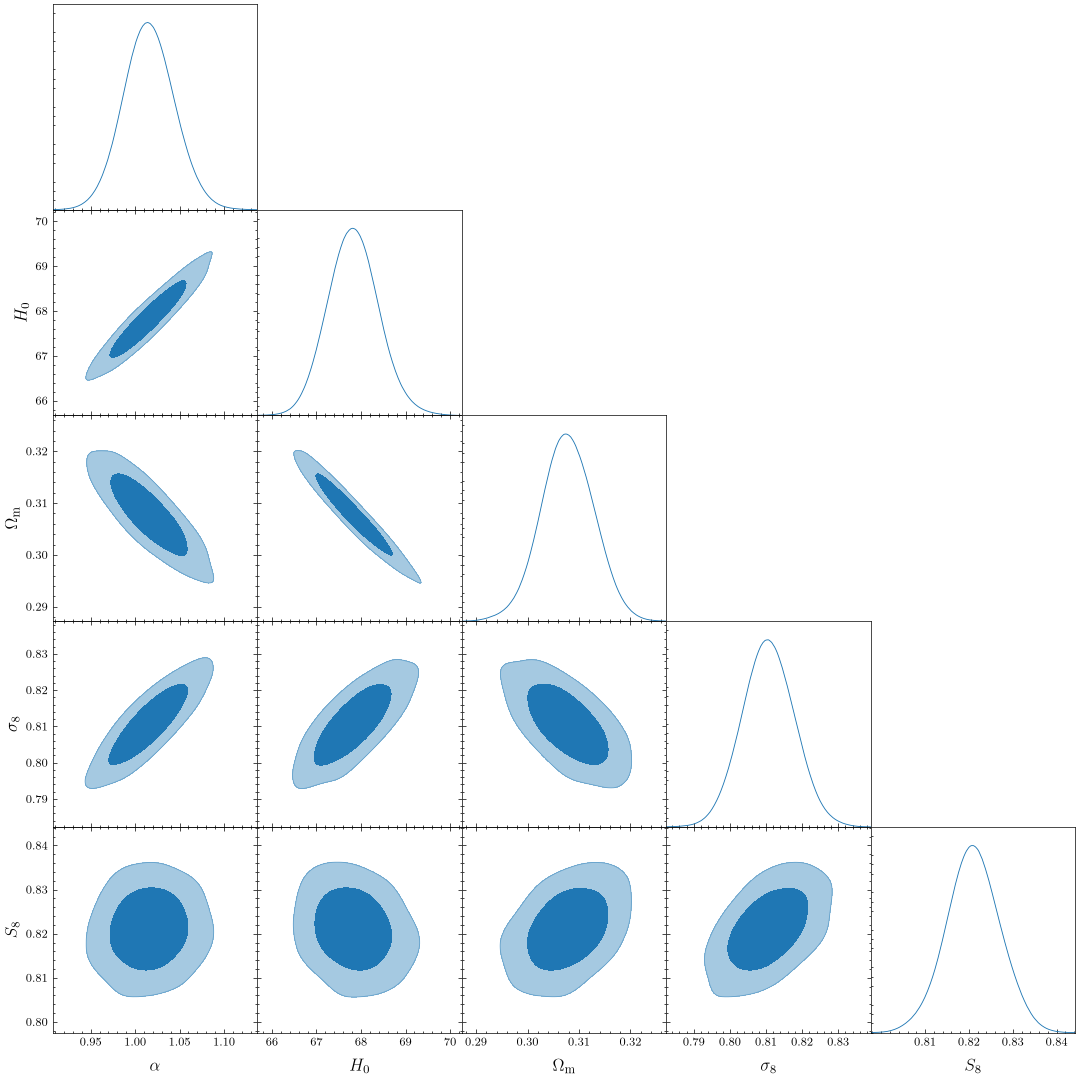

In [ ]:

# Build alpha-version sample sets for triangle plots.
# addDerived() doesn't fully register new params in getdist's KDE pipeline,
# so we build fresh MCSamples objects with sqrt_k_eta0 scaled and renamed to alpha.
from getdist import MCSamples as _MCSamples


def _alpha_samples(samples_dict, k_alpha):
    """Return a new dict of MCSamples with sqrt_k_eta0 -> alpha = sqrt_k_eta0 / k_alpha."""
    result = {}
    for rk, s in samples_dict.items():
        plist = s.getParamNames().list()
        if "sqrt_k_eta0" not in plist or k_alpha is None:
            result[rk] = s
            continue
        idx = plist.index("sqrt_k_eta0")
        new_arr = s.samples.copy()
        new_arr[:, idx] /= k_alpha
        names, labels = [], []
        for pn in s.getParamNames().names:
            if pn.name == "sqrt_k_eta0":
                names.append("alpha")
                labels.append(r"\alpha")
            else:
                names.append(pn.name)
                labels.append(pn.label)
        result[rk] = _MCSamples(
            samples=new_arr,
            weights=s.weights,
            loglikes=getattr(s, "loglikes", None),
            names=names,
            labels=labels,
            settings={"ignore_rows": 0},
        )
    return result


_asamples = _alpha_samples({k: samples[k] for k in chosen}, K_ALPHA)

ALPHA_HEADLINE = ["alpha", "H0", "Omega_m", "sigma8", "S8"]
ALPHA_FULL = [p if p != "sqrt_k_eta0" else "alpha" for p in FULL_PARAMS]

# Headline triangle (alpha + key cosmological params)
_ = triangle(_asamples, ALPHA_HEADLINE, "grea_alpha_headline_triangle.pdf",
             colors=run_colors, display_labels=run_labels_display, filled=True)

Saved figs/grea_alpha_full_triangle.pdf


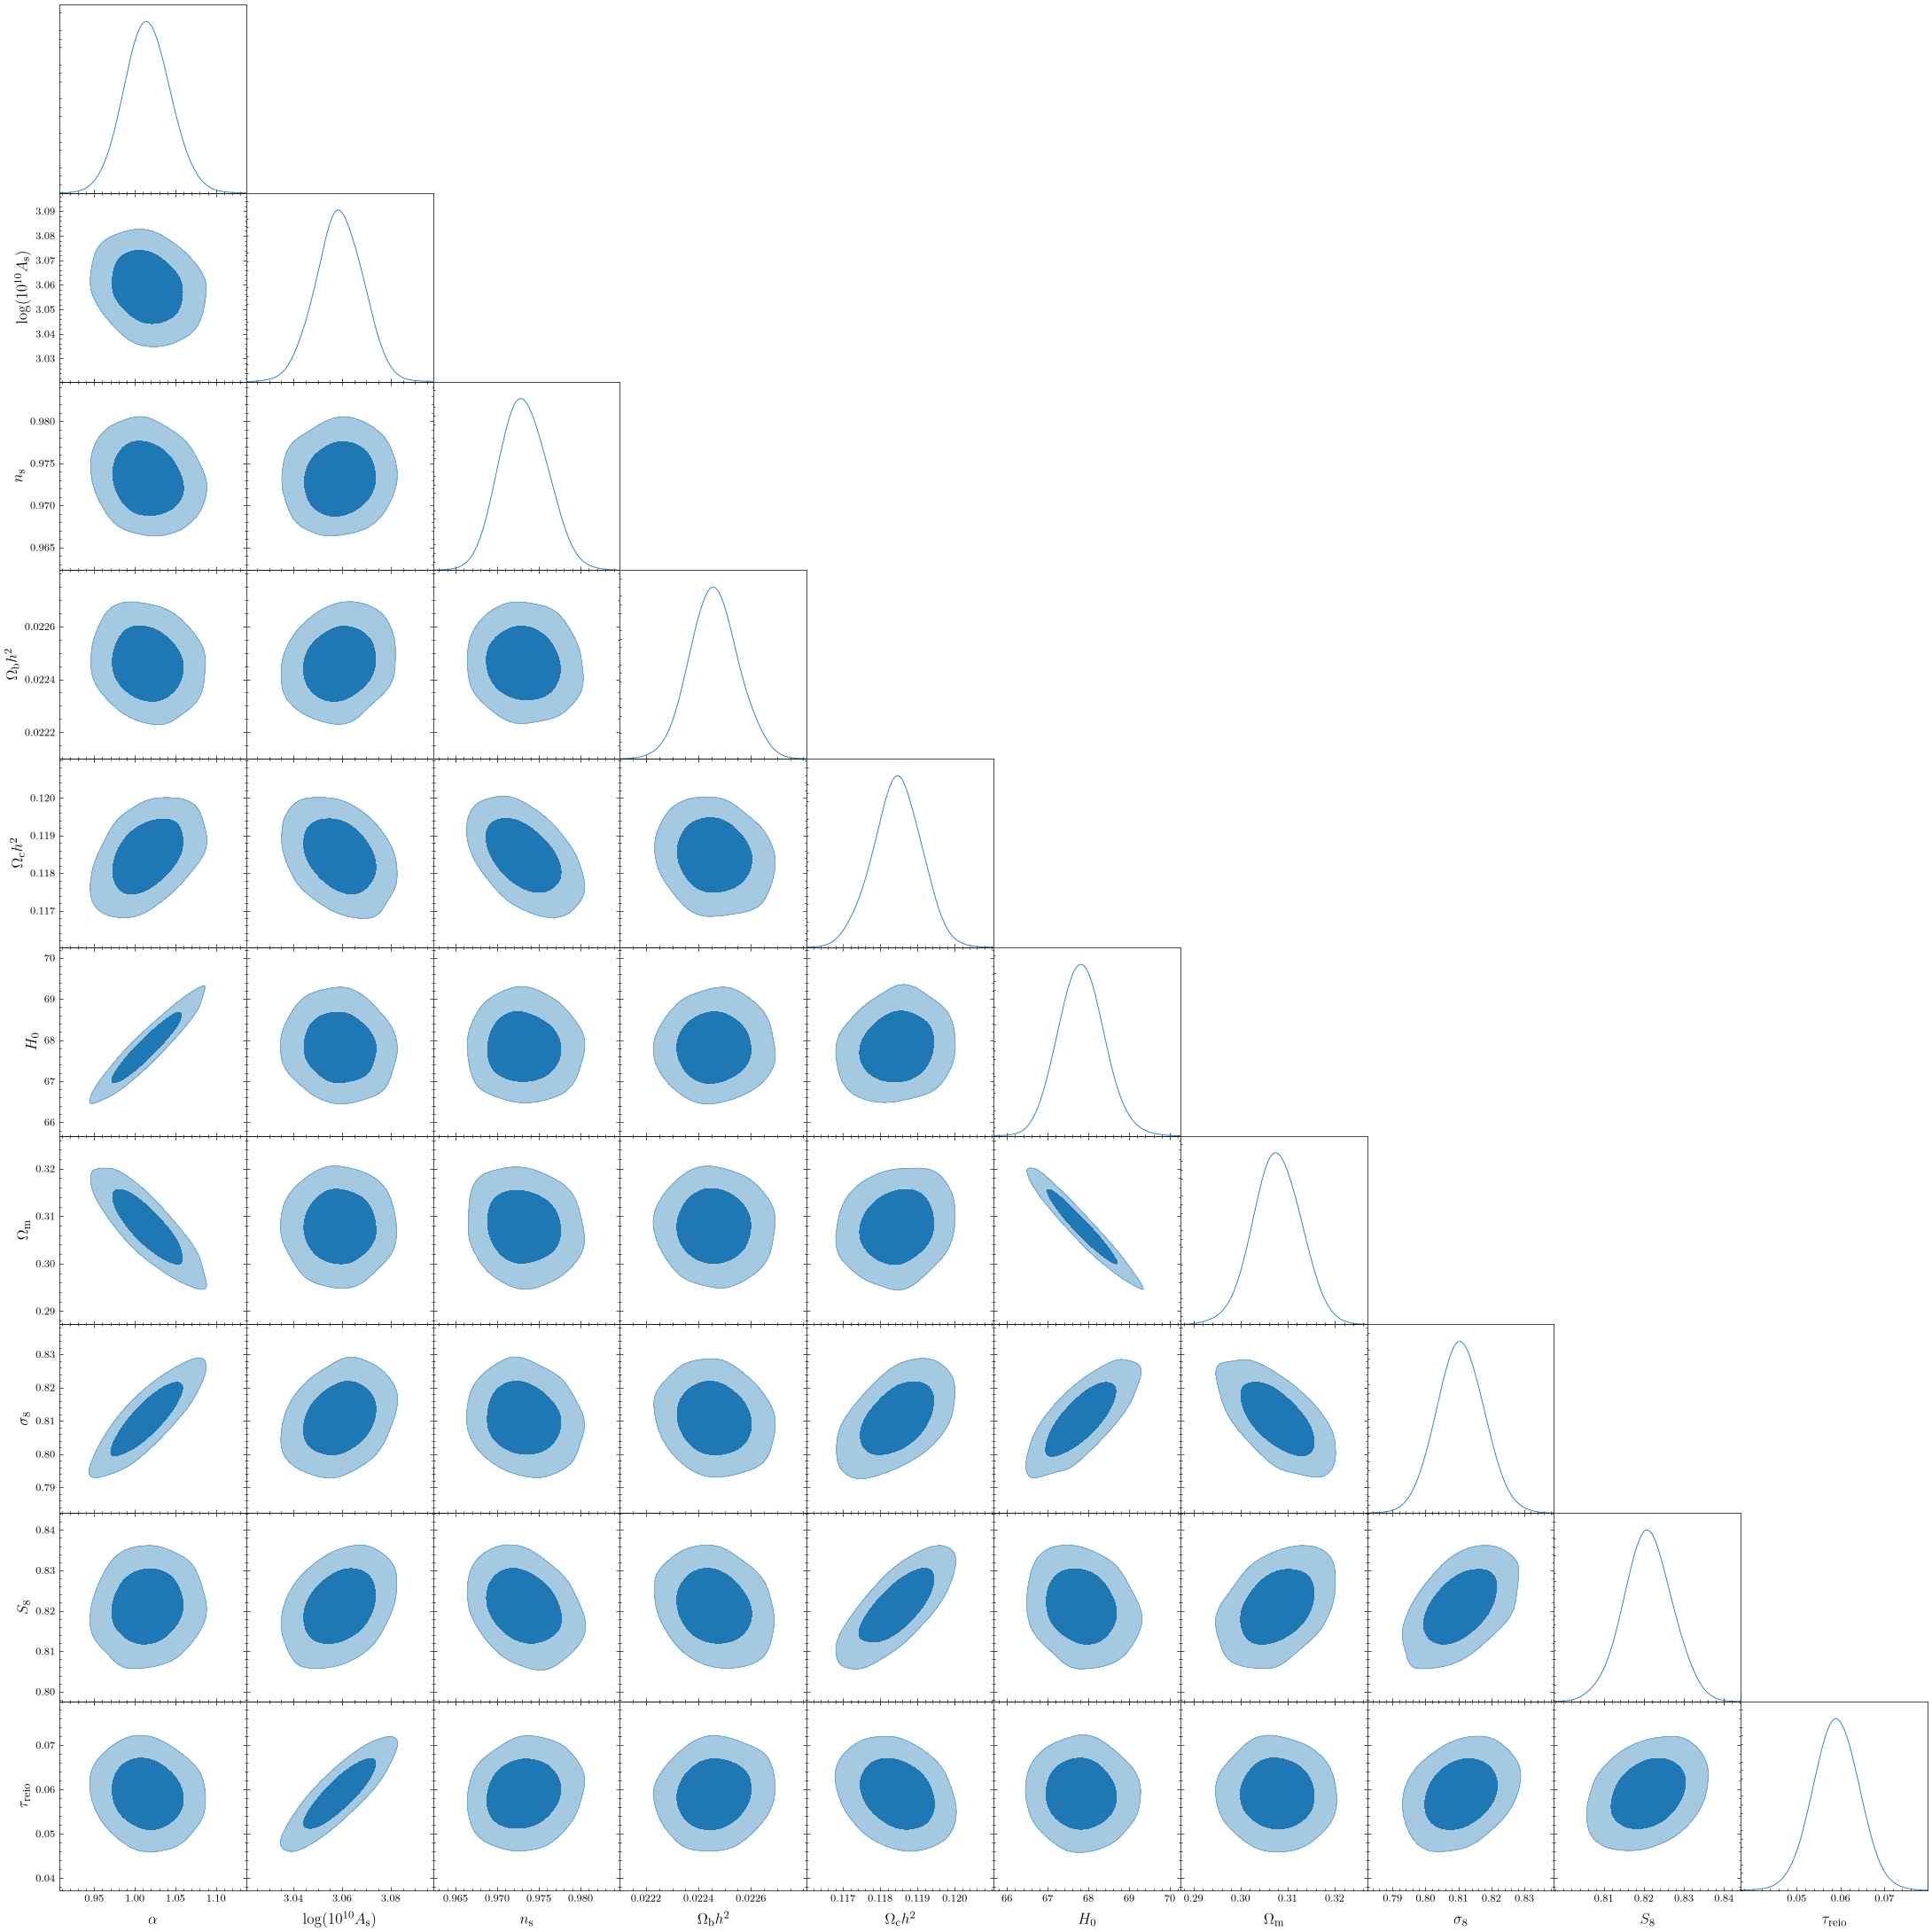

In [ ]:

# Full triangle (all cosmological params, alpha in place of sqrt_k_eta0)
_ = triangle(_asamples, ALPHA_FULL, "grea_alpha_full_triangle.pdf",
             colors=run_colors, display_labels=run_labels_display, filled=True)